In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries ready!")

All libraries ready!


In [ ]:
dept = pd.read_csv('departments.csv')
emp = pd.read_csv('employees.csv')
tickets = pd.read_csv('tickets.csv')

print("departments shape:", dept.shape)
print("employees shape:", emp.shape)
print("tickets shape:", tickets.shape)

departments shape: (20, 5)
employees shape: (500, 13)
tickets shape: (5000, 14)


In [ ]:
print("=== EMPLOYEES INFO ===")
print(emp.info())
print("\n=== TICKETS INFO ===")
print(tickets.info())

=== EMPLOYEES INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   emp_id              500 non-null    object 
 1   name                500 non-null    object 
 2   dept_id             500 non-null    object 
 3   designation         500 non-null    object 
 4   experience_years    500 non-null    int64  
 5   salary_lakhs        500 non-null    float64
 6   gender              500 non-null    object 
 7   joining_date        500 non-null    object 
 8   performance_rating  500 non-null    int64  
 9   certifications      500 non-null    int64  
 10  attrition           500 non-null    object 
 11  work_mode           500 non-null    object 
 12  overtime            500 non-null    object 
dtypes: float64(1), int64(3), object(9)
memory usage: 50.9+ KB
None

=== TICKETS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeInde

In [ ]:
print("=== NULL VALUES ===")
print("\nDepartments nulls:")
print(dept.isnull().sum())
print("\nEmployees nulls:")
print(emp.isnull().sum())
print("\nTickets nulls:")
print(tickets.isnull().sum())

=== NULL VALUES ===

Departments nulls:
dept_id                0
dept_name              0
location               0
head_count             0
annual_budget_lakhs    0
dtype: int64

Employees nulls:
emp_id                0
name                  0
dept_id               0
designation           0
experience_years      0
salary_lakhs          0
gender                0
joining_date          0
performance_rating    0
certifications        0
attrition             0
work_mode             0
overtime              0
dtype: int64

Tickets nulls:
ticket_id             0
emp_id                0
dept_id               0
ticket_type           0
category              0
priority              0
status                0
raised_date           0
resolved_date         0
resolution_hrs        0
sla_breached          0
reopen_count          0
satisfaction_score    0
assigned_to           0
dtype: int64


In [ ]:
print("=== EMPLOYEES STATISTICS ===")
print(emp.describe())
print("\n=== TICKETS STATISTICS ===")
print(tickets.describe())

=== EMPLOYEES STATISTICS ===
       experience_years  salary_lakhs  performance_rating  certifications
count         500.00000    500.000000           500.00000      500.000000
mean            7.43000     14.570600             3.36200        2.522000
std             4.66182      6.107389             1.00248        1.710956
min             0.00000      3.500000             1.00000        0.000000
25%             3.75000      9.500000             3.00000        1.000000
50%             8.00000     14.850000             3.00000        3.000000
75%            12.00000     19.625000             4.00000        4.000000
max            15.00000     25.000000             5.00000        5.000000

=== TICKETS STATISTICS ===
       resolution_hrs  reopen_count  satisfaction_score
count     5000.000000   5000.000000         5000.000000
mean        34.618900      0.440800            3.617200
std         27.166709      0.749004            1.063621
min          1.000000      0.000000            1.0000

In [ ]:
# Convert date columns to datetime
emp['joining_date'] = pd.to_datetime(emp['joining_date'])
tickets['raised_date'] = pd.to_datetime(tickets['raised_date'])
tickets['resolved_date'] = pd.to_datetime(tickets['resolved_date'])

# Add helper columns
tickets['month_raised'] = tickets['raised_date'].dt.to_period('M')
tickets['year_raised'] = tickets['raised_date'].dt.year

# Experience band for employees
emp['experience_band'] = pd.cut(
    emp['experience_years'],
    bins=[0, 2, 5, 10, 20],
    labels=['Junior (0-2)', 'Mid (3-5)', 'Senior (6-10)', 'Expert (10+)']
)

print("Date columns fixed!")
print(tickets[['raised_date','resolved_date','month_raised','year_raised']].head())

Date columns fixed!
  raised_date       resolved_date month_raised  year_raised
0  2022-10-20 2022-10-22 05:36:00      2022-10         2022
1  2021-08-03 2021-08-07 04:24:00      2021-08         2021
2  2021-11-26 2021-11-26 22:24:00      2021-11         2021
3  2022-11-07 2022-11-07 01:54:00      2022-11         2022
4  2023-04-24 2023-04-26 05:42:00      2023-04         2023


In [ ]:
# Merge tickets with departments
tickets_dept = tickets.merge(dept, on='dept_id', how='left')

# Merge employees with departments
emp_dept = emp.merge(dept, on='dept_id', how='left')

# Full merged dataset
full_df = tickets.merge(emp, left_on='emp_id', right_on='emp_id', how='left')
full_df = full_df.merge(dept, left_on='dept_id_x', right_on='dept_id', how='left')

print("Merged datasets ready!")
print("Full merged shape:", full_df.shape)

Merged datasets ready!
Full merged shape: (5000, 34)


<Figure size 1000x500 with 0 Axes>

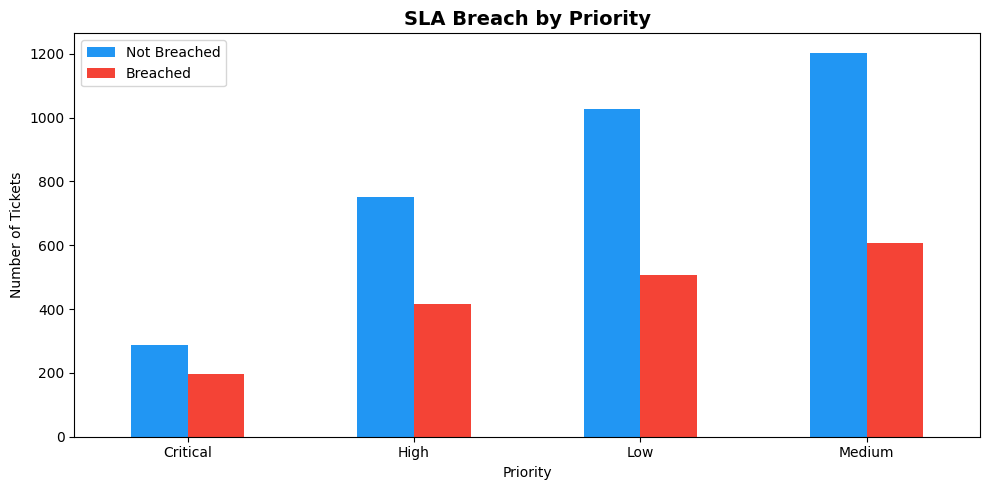

Chart 1 saved!


In [ ]:
plt.figure(figsize=(10, 5))
sla_priority = tickets.groupby(['priority', 'sla_breached']).size().unstack()
sla_priority.plot(kind='bar', figsize=(10,5), color=['#2196F3','#F44336'])
plt.title('SLA Breach by Priority', fontsize=14, fontweight='bold')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)
plt.legend(['Not Breached', 'Breached'])
plt.tight_layout()
plt.savefig('chart1_sla_breach_priority.png', dpi=150)
plt.show()
print("Chart 1 saved!")

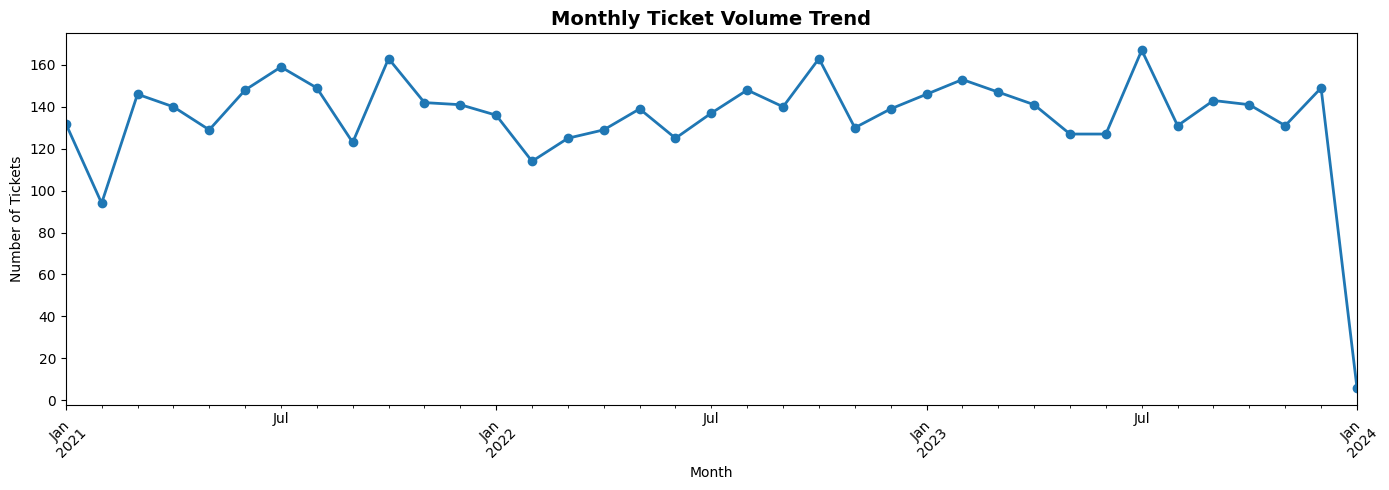

Chart 2 saved!


In [ ]:
plt.figure(figsize=(14, 5))
monthly = tickets.groupby('month_raised').size()
monthly.plot(kind='line', marker='o', color='#1F77B4', linewidth=2)
plt.title('Monthly Ticket Volume Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150)
plt.show()
print("Chart 2 saved!")

<Figure size 1400x600 with 0 Axes>

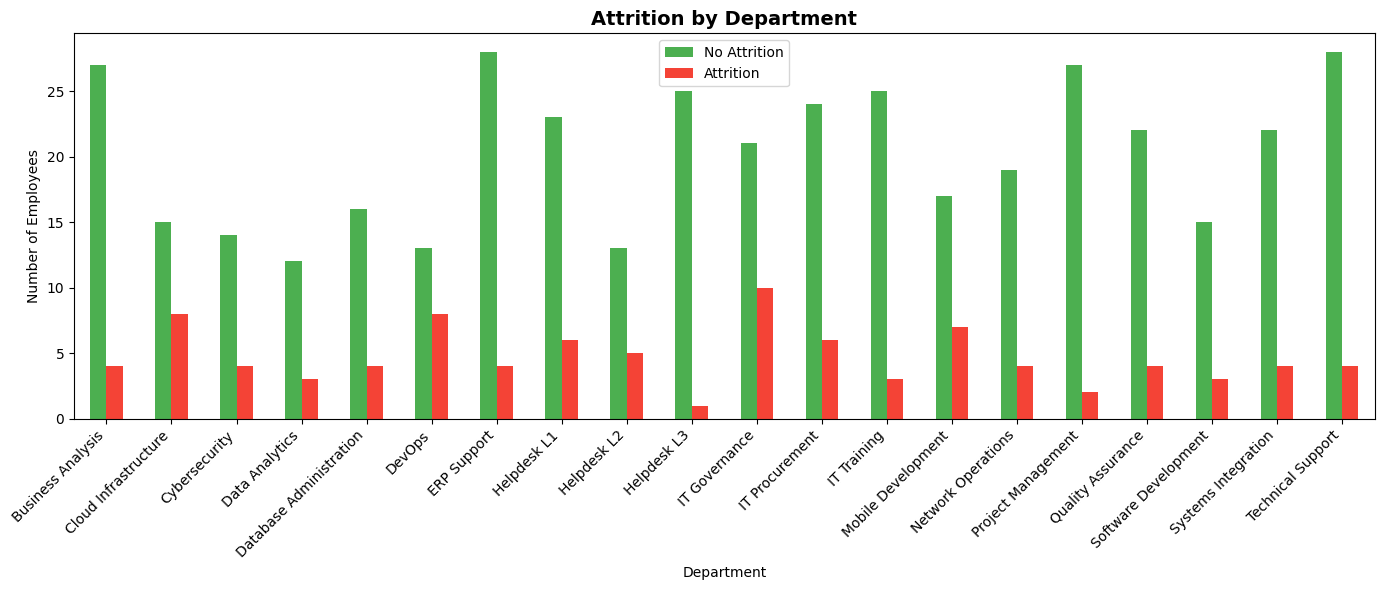

Chart 3 saved!


In [ ]:
plt.figure(figsize=(14, 6))
attrition_dept = emp_dept.groupby(['dept_name', 'attrition']).size().unstack()
attrition_dept.plot(kind='bar', figsize=(14,6), color=['#4CAF50','#F44336'])
plt.title('Attrition by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.savefig('chart3_attrition_dept.png', dpi=150)
plt.show()
print("Chart 3 saved!")

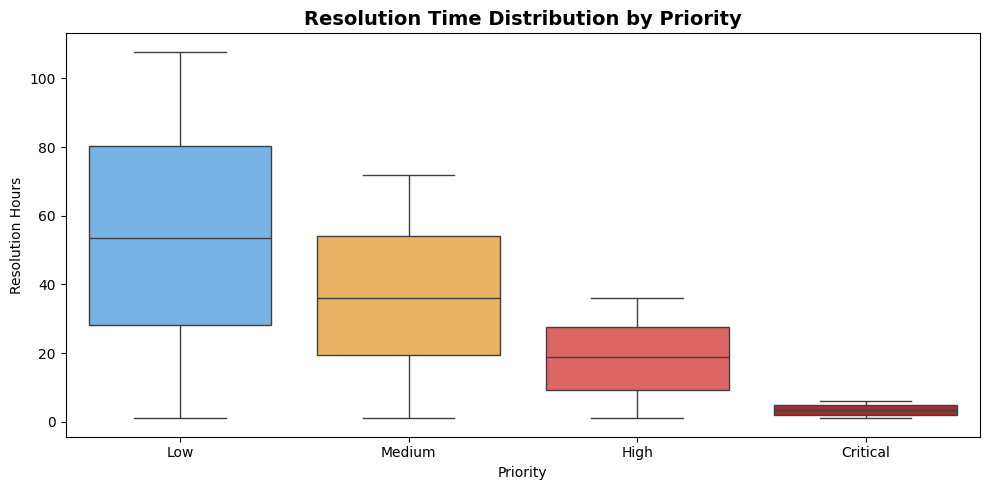

Chart 4 saved!


In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=tickets, x='priority', y='resolution_hrs',
            order=['Low','Medium','High','Critical'],
            palette=['#64B5F6','#FFB74D','#EF5350','#B71C1C'])
plt.title('Resolution Time Distribution by Priority', fontsize=14, fontweight='bold')
plt.xlabel('Priority')
plt.ylabel('Resolution Hours')
plt.tight_layout()
plt.savefig('chart4_resolution_distribution.png', dpi=150)
plt.show()
print("Chart 4 saved!")

<Figure size 800x500 with 0 Axes>

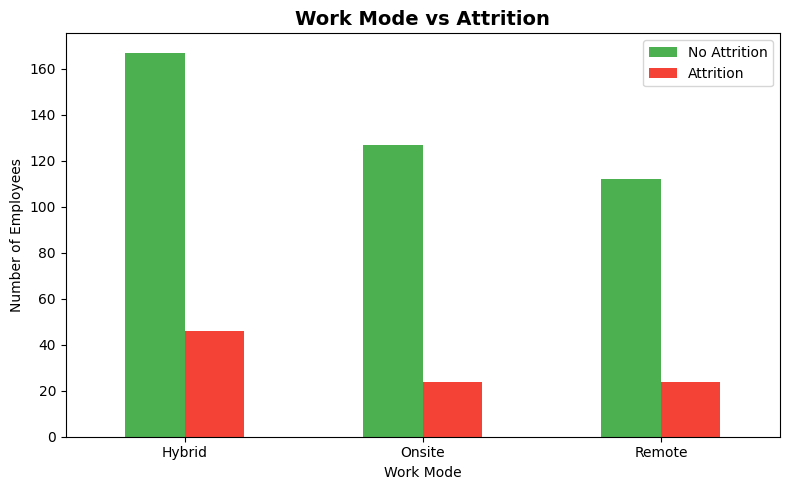

Chart 5 saved!


In [ ]:
plt.figure(figsize=(8, 5))
workmode_attr = emp.groupby(['work_mode', 'attrition']).size().unstack()
workmode_attr.plot(kind='bar', figsize=(8,5), color=['#4CAF50','#F44336'])
plt.title('Work Mode vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Work Mode')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.savefig('chart5_workmode_attrition.png', dpi=150)
plt.show()
print("Chart 5 saved!")

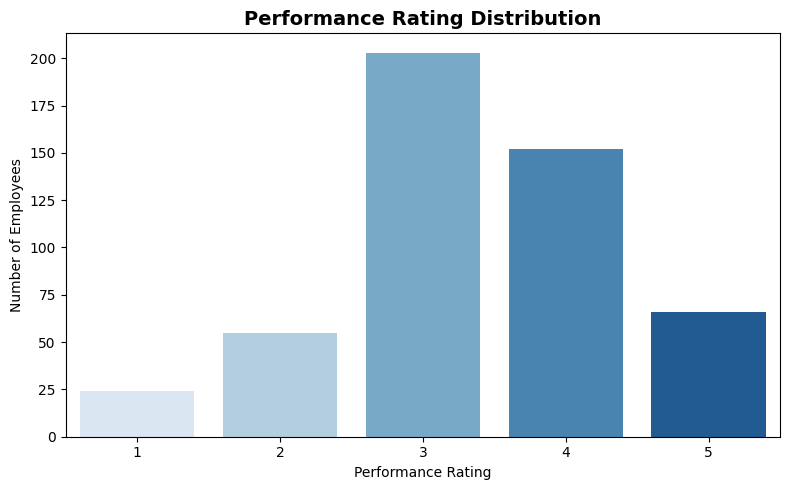

Chart 6 saved!


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=emp, x='performance_rating', palette='Blues')
plt.title('Performance Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Performance Rating')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('chart6_performance_distribution.png', dpi=150)
plt.show()
print("Chart 6 saved!")

In [ ]:
print("=" * 50)
print("   IT HELPDESK PERFORMANCE ANALYTICS SUMMARY")
print("=" * 50)
print(f"Total Tickets          : {len(tickets):,}")
print(f"SLA Breach Rate        : {(tickets['sla_breached']=='Yes').mean()*100:.1f}%")
print(f"Avg Resolution Time    : {tickets['resolution_hrs'].mean():.1f} hrs")
print(f"Avg Satisfaction Score : {tickets['satisfaction_score'].mean():.2f} / 5")
print(f"Total Employees        : {len(emp):,}")
print(f"Attrition Rate         : {(emp['attrition']=='Yes').mean()*100:.1f}%")
print(f"Avg Performance Rating : {emp['performance_rating'].mean():.2f} / 5")
print(f"Total Departments      : {len(dept):,}")
print("=" * 50)

   IT HELPDESK PERFORMANCE ANALYTICS SUMMARY
Total Tickets          : 5,000
SLA Breach Rate        : 34.6%
Avg Resolution Time    : 34.6 hrs
Avg Satisfaction Score : 3.62 / 5
Total Employees        : 500
Attrition Rate         : 18.8%
Avg Performance Rating : 3.36 / 5
Total Departments      : 20
